# Estimating $H_0$ from Cepheid variables

The first rung of the distance ladder. Cepheids obey a tight period-luminosity relation, so
timing a Cepheid's pulsation gives its absolute magnitude, and comparing that to its apparent
magnitude gives a distance. No cosmological model is assumed anywhere.

1. Recession velocities of a galaxy cluster from the $H\alpha$ redshift.
2. Calibrate the Leavitt law on ~1400 Milky Way Cepheids with Gaia parallaxes.
3. Apply it to Cepheids *in* the cluster galaxies to get distances.
4. Fit $v = H_0 d$.

This is the purely local, geometric route, which is what makes it a cross-check on the
supernova fit in `SNe/` and the CMB fit in `CMB/`.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Section 1: Redshifts and radial velocities of the cluster galaxies

`Data/galaxy.csv` holds one row per galaxy in the cluster: its name, the observed wavelength
of the $H\alpha$ line $\lambda_{H\alpha}$, and its Right Ascension and Declination at J2000.0
([what RA and Dec mean](https://en.wikipedia.org/wiki/Equatorial_coordinate_system)).

In [24]:
galaxy_data = pd.read_csv('Data/galaxy.csv')

print(galaxy_data.columns.tolist())

['Name', 'Observed Wavelength of H-alpha', 'Apparent Mag', 'RA J2000.0', 'Dec J2000.0']


The galaxies recede, so $H\alpha$ arrives [redshifted](https://en.wikipedia.org/wiki/Redshift)
from its rest wavelength $\lambda_0 = 6562.8\ \text{Å}$:

$$z = \frac{\lambda_{\rm obs} - \lambda_0}{\lambda_0}, \qquad v_r = cz$$

The wavelengths are already corrected for the Earth's motion about the Sun and the Sun's about
the Galactic centre, so $v_r$ is the galaxy's velocity relative to us directly.

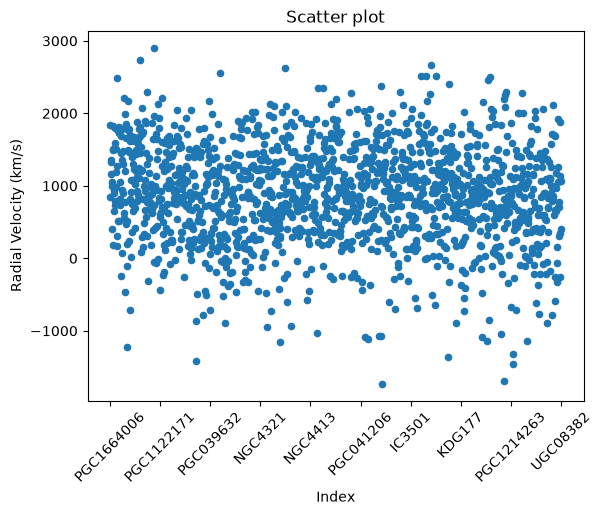

In [25]:
galaxy_data['redshift'] = ((galaxy_data['Observed Wavelength of H-alpha'] - 6562.8) / 6562.8)
galaxy_data['v_r'] = (galaxy_data['redshift'] * 299792.458)

#plot with  x axis as index and y axis as radial velocity
plot = galaxy_data.plot.scatter(x='Name', y='v_r', title='Scatter plot', xlabel='Index', ylabel='Radial Velocity (km/s)')

plt.xticks(np.linspace(0, len(galaxy_data)-1, num=10, dtype=int), rotation=45)
plt.show()

To look at the geometry of the cluster the coordinates need to be in decimal degrees rather than
the sexagesimal $a^\circ\,b^m\,c^s$ format they ship in, so they are converted below.

In [26]:
temp = galaxy_data['RA J2000.0'].str.split(' ', expand=True)
galaxy_data['RA J2000.0'] = temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600
temp = galaxy_data['Dec J2000.0'].str.split(' ', expand=True)
galaxy_data['Dec J2000.0'] = temp[0].astype(float) + temp[1].astype(float) / 60 + temp[2].astype(float) / 3600

***

### Angular size

Using the spherical law of cosines for the separation between members,

$$\cos\theta_{12} = \sin\delta_1\sin\delta_2 + \cos\delta_1\cos\delta_2\cos(\alpha_1-\alpha_2)$$

(rather than treating RA/Dec as a flat plane), the cluster spans $\approx 31.5^\circ$. The extent
is lopsided: $\approx 1.8^\circ$ in RA against $\approx 31.5^\circ$ in Dec, so the members trace a
strip rather than a round patch.

### Rotation

The plot below colours members by radial velocity. Bulk rotation would appear as a smooth velocity
*gradient* across the cluster. A random mix instead means virial motion, i.e. random orbits in the
cluster potential.

This matters for Section 4: any velocity that is not Hubble flow is noise in the $H_0$ fit.

***

RA extent: 1.778 deg
Dec extent: 31.496 deg
Max angular separation in cluster: 31.500 deg


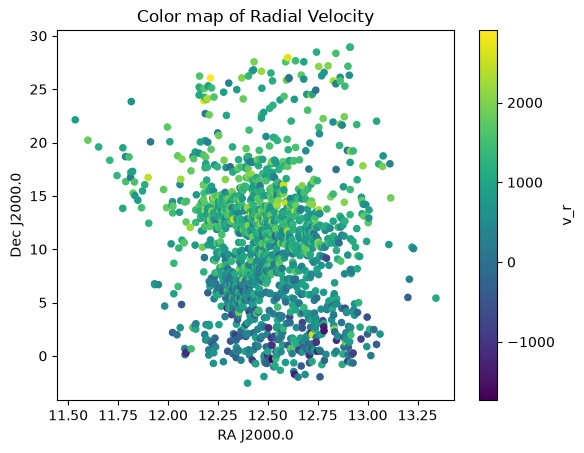

In [27]:
#plot a color map of radial velocity with ra and dec as axes    
plot = galaxy_data.plot.scatter(x='RA J2000.0', y='Dec J2000.0', c='v_r', cmap='viridis', title='Color map of Radial Velocity', xlabel='RA J2000.0', ylabel='Dec J2000.0', colorbar=True)

ra = np.radians(galaxy_data['RA J2000.0'])
dec = np.radians(galaxy_data['Dec J2000.0'])

# mean dec, for the cos(dec) correction on RA spread
dec_mean = dec.mean()

ra_extent = (ra.max() - ra.min()) * np.cos(dec_mean)   # radians, RA corrected
dec_extent = dec.max() - dec.min()                      # radians

ra_extent_deg = np.degrees(ra_extent)
dec_extent_deg = np.degrees(dec_extent)

print(f"RA extent: {ra_extent_deg:.3f} deg")
print(f"Dec extent: {dec_extent_deg:.3f} deg")

#---

from itertools import combinations

max_sep = 0
coords = list(zip(ra, dec))
for (ra1, dec1), (ra2, dec2) in combinations(coords, 2):
    # angular separation via the spherical law of cosines
    cos_sep = np.sin(dec1)*np.sin(dec2) + np.cos(dec1)*np.cos(dec2)*np.cos(ra1 - ra2)
    sep = np.degrees(np.arccos(np.clip(cos_sep, -1, 1)))
    max_sep = max(max_sep, sep) 

print(f"Max angular separation in cluster: {max_sep:.3f} deg")

# Section 2: Calibrating the Leavitt law on Gaia Cepheids

***

[Gaia](https://en.wikipedia.org/wiki/Gaia_(spacecraft)) has mapped the Milky Way in three
dimensions. What matters here is that its parallaxes fix distances to Galactic Cepheids
*geometrically*, with no ladder and no model. That is the anchor needed before the
period-luminosity relation can be used on anything further away.

In [28]:
gaia_data = pd.read_csv('Data/gaia.csv')

Cepheids are variable stars that pulsate radially, varying in both diameter and temperature. They
**change in brightness** with a **well-defined, stable period and amplitude**.

`Data/gaia.csv` contains about 5000 Cepheids in our own galaxy, with the fields:

* unique source ID
* [parallax](https://en.wikipedia.org/wiki/Stellar_parallax) $\varpi$, in milliarcseconds
* mean **apparent** magnitude $m$
* pulsation period $P$, in days

Classical Cepheids follow the
[period-luminosity law](https://en.wikipedia.org/wiki/Period-luminosity_relation#The_relations),
or Leavitt law, relating pulsation period $P$ to absolute magnitude $M$:

$$M = \alpha \log_{10}\left(P\ \text{[days]}\right) + \beta$$

Longer-period Cepheids are intrinsically brighter, and magnitudes run backwards, so $\alpha < 0$.

***

Calibration takes two steps:

$$d\ [\text{pc}] = \frac{1000}{\varpi\ [\text{mas}]}, \qquad M = m - 5\left(\log_{10} d - 1\right)$$

then fit $M$ against $\log_{10} P$.

Fitting all 1361 stars gives a residual scatter of $1.53$ mag, far too large (a real Leavitt law
scatters by $0.2$ to $0.3$ mag), and implies magnitudes as faint as $M = +10$, impossible for a
supergiant. The sample is contaminated.

**Choosing a rejection method.** The instinct is to cut on parallax quality, since $d = 1000/\varpi$
is unreliable for the 1020 stars beyond 3 kpc. That fails here:

| cut | N | $\alpha$ | scatter |
|---|---|---|---|
| none | 1361 | $-1.750$ | 1.53 |
| $\varpi > 0.2$ | 765 | $-2.351$ | 1.79 |
| $\varpi > 0.5$ | 143 | $-5.211$ | 2.41 |
| $\varpi > 1.0$ | 43 | $-6.954$ | 2.72 |

The slope never stabilises and the scatter worsens. That is Malmquist bias: a parallax cut is a
*distance* cut, and in a magnitude-limited sample distant stars are preferentially the bright
long-period ones. Cutting on distance cuts on period, the very axis being fitted.

The safe alternative is **iterative sigma clipping on residuals**: fit, keep
$|r_i| \le 3\sigma_r$, refit, repeat to convergence. It rejects symmetrically in residual space, so
it selects on neither distance nor period.

alpha: -1.482025683653527, beta: 0.07818455765719293
kept 1324 of 1361 stars (37 clipped), residual scatter = 1.230 mag


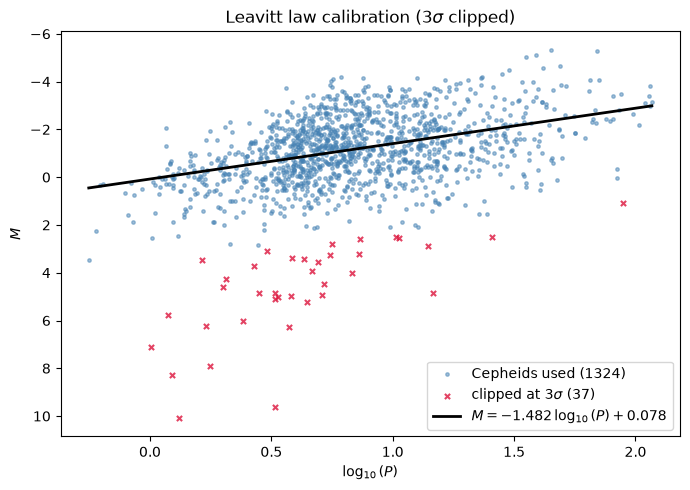

In [29]:
gaia_data['parallax'] = pd.to_numeric(gaia_data['parallax'])
gaia_data['d in pc'] = 1000 / gaia_data['parallax']

#use the distance to calculate the absolute magnitude of the stars using the formula M = m - 5 * (log10(d) - 1)
gaia_data['M']= gaia_data['mean apparent magnitude'] - 5 * (np.log10(gaia_data['d in pc']) - 1)

gaia_data['log10_P'] = np.log10(gaia_data['time period'])

x_all = gaia_data['log10_P'].values
y_all = gaia_data['M'].values


def sigma_clip_fit(x, y, nsigma=3.0, max_iter=20):
    # Straight-line fit with iterative sigma clipping on the residuals.
    # Clipping symmetrically in residual space avoids selecting on distance or
    # period, either of which would bias the slope (see the note above).
    keep = np.ones(len(x), dtype=bool)
    for _ in range(max_iter):
        coeffs = np.polyfit(x[keep], y[keep], 1)
        residuals = y - np.polyval(coeffs, x)
        new_keep = np.abs(residuals) <= nsigma * residuals[keep].std()
        if (new_keep == keep).all():      # converged
            break
        keep = new_keep
    return coeffs, keep, residuals[keep].std()


poly, keep, scatter = sigma_clip_fit(x_all, y_all, nsigma=3.0)
alpha, beta = poly

print(f"alpha: {alpha}, beta: {beta}")
print(f"kept {keep.sum()} of {len(keep)} stars "
      f"({(~keep).sum()} clipped), residual scatter = {scatter:.3f} mag")

# plot the survivors and the clipped stars separately so the cut is visible
plt.figure(figsize=(7, 5))
plt.scatter(x_all[keep], y_all[keep], s=6, alpha=0.5,
            color='steelblue', label=f'Cepheids used ({keep.sum()})')
plt.scatter(x_all[~keep], y_all[~keep], s=14, alpha=0.8, marker='x',
            color='crimson', label=f'clipped at 3$\\sigma$ ({(~keep).sum()})')

x = np.linspace(x_all.min(), x_all.max(), 100)
plt.plot(x, np.polyval(poly, x), color='black', lw=2,
         label=f'$M = {alpha:.3f}\\,\\log_{{10}}(P) + {beta:.3f}$')

plt.gca().invert_yaxis()      # magnitudes: brighter is up
plt.xlabel('$\\log_{10}(P)$')
plt.ylabel('$M$')
plt.title('Leavitt law calibration (3$\\sigma$ clipped)')
plt.legend()
plt.tight_layout()
plt.show()

The clipped fit returns

$$\alpha = -1.482, \qquad \beta = 0.078$$

with 37 of 1361 rejected and scatter $1.23$ mag.

Still an order of magnitude worse than a real Leavitt law. Clipping removes extreme outliers but
cannot fix a sample whose bulk is noisy, and with no parallax uncertainty column there is no way to
tell which distances are untrustworthy. This scatter propagates into every distance in Section 3.

***
### The magnitude system

Observed brightness is **apparent magnitude** $m$, with

$$m_1 - m_2 = 2.5 \log_{10}\left(\frac{f_1}{f_2}\right)$$

**Absolute magnitude** $M$ is what the star would show at exactly 10 pc, so it depends only on
intrinsic brightness. The two are linked by the distance modulus

$$m - M = 5\log_{10}\left(d\ [\text{pc}]\right) - 5$$

the same quantity fitted against the Pantheon supernovae in `SNe/`. There it comes from a
cosmological model; here it is measured directly.

***

# Section 3: Distances to the cluster galaxies

With the relation calibrated, apply it to Cepheids in *other* galaxies. This is how the Hubble
Space Telescope measured distances to the Virgo cluster.

`Data/cepheid.csv` holds the Cepheids identified in the cluster galaxies: ID, host galaxy, apparent
magnitude $m$, and period $P$.

In [30]:
cepheid_data = pd.read_csv('Data/cepheid.csv')

# Leavitt law -> absolute magnitude -> distance, for every cepheid
cepheid_data['log10_P'] = np.log10(cepheid_data['Period'])
cepheid_data['M'] = alpha * cepheid_data['log10_P'] + beta
cepheid_data['star_d in pc'] = 10 ** ((cepheid_data['Apparent Magnitude'] - cepheid_data['M'] + 5) / 5)


def remove_outliers(group):
    # Drop cepheids more than 2 sigma from their galaxy's mean distance.
    # Galaxies with a single cepheid have an undefined std, so they are kept
    # as-is rather than being silently dropped.
    mean = group['star_d in pc'].mean()
    std = group['star_d in pc'].std()
    if not np.isfinite(std) or std == 0:
        return group
    return group[np.abs(group['star_d in pc'] - mean) <= (2 * std)]


cepheid_clean = (cepheid_data
                 .groupby('Galaxy_ID', group_keys=False)[cepheid_data.columns.tolist()]
                 .apply(remove_outliers))

new_mean_distances = cepheid_clean.groupby('Galaxy_ID')['star_d in pc'].mean()
outliers_removed = (cepheid_data.groupby('Galaxy_ID').size()
                    - cepheid_clean.groupby('Galaxy_ID').size())

print(f"cepheids: {len(cepheid_data)} -> {len(cepheid_clean)} "
      f"({len(cepheid_data) - len(cepheid_clean)} removed)")
print(f"galaxies retained: {new_mean_distances.notna().sum()} of "
      f"{cepheid_data['Galaxy_ID'].nunique()}")
print(f"fewest cepheids in any galaxy: {cepheid_data.groupby('Galaxy_ID').size().min()}")

cepheids: 5000 -> 4934 (66 removed)
galaxies retained: 1470 of 1470
fewest cepheids in any galaxy: 1


The Leavitt law gives $M$ from $P$, and inverting the distance modulus gives

$$d = 10^{(m - M + 5)/5}\ \text{pc}$$

Averaging over a galaxy's Cepheids gives its distance.

Outliers matter here for a different reason than Section 2. Some entries are foreground or
background Cepheids that only *appear* to belong to the galaxy, falling along the same line of
sight. Since $d$ is exponential in $(m-M)$, one interloper drags the mean badly, so they are cut at
$2\sigma$ about each galaxy's own mean.

One trap: the sparsest galaxies hold a **single** Cepheid, and $\sigma$ of one value is `NaN`. Every
comparison against `NaN` is `False`, so a naive clip silently deletes those 196 galaxies. The guard
below keeps them.

***

# Section 4: Fitting the Hubble constant

[Hubble's law](https://en.wikipedia.org/wiki/Hubble%27s_law):

$$v = H_0 d$$

Velocities come from Section 1, distances from Section 3. Rather than reading off one pair, a
Gaussian is fitted to each distribution and the means used.

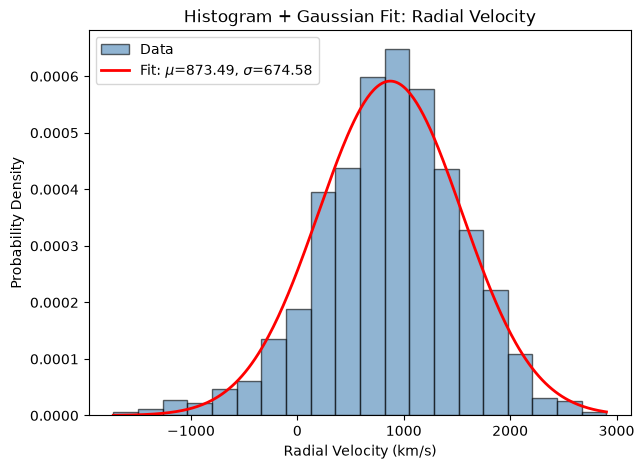

Radial Velocity: mean = 873.485 km/s, std = 674.583 km/s


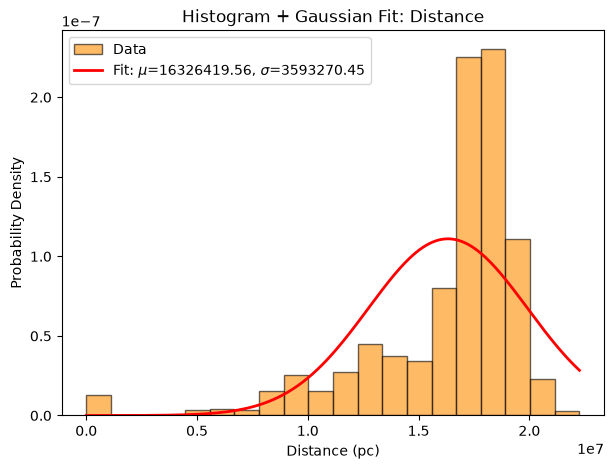

Distance: mean = 16326419.561 pc, std = 3593270.452 pc


In [34]:
def fit_and_plot_gaussian(data, label, unit, color='steelblue', bins=20):
    data = np.asarray(data)
    data = data[~np.isnan(data)]  # drop any NaNs (e.g. galaxies with no cepheid match)

    # Fit a Gaussian via MLE (returns mean, std)
    mu, sigma = norm.fit(data)

    # Plot histogram (normalized to a density so it's comparable to the pdf)
    plt.figure(figsize=(7, 5))
    counts, bin_edges, _ = plt.hist(
        data, bins=bins, density=True, alpha=0.6, color=color,
        edgecolor='black', label='Data'
    )

    # Overlay fitted Gaussian
    x = np.linspace(data.min(), data.max(), 300)
    plt.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=2,
              label=f'Fit: $\\mu$={mu:.2f}, $\\sigma$={sigma:.2f}')

    plt.xlabel(f'{label} ({unit})')
    plt.ylabel('Probability Density')
    plt.title(f'Histogram + Gaussian Fit: {label}')
    plt.legend()
    plt.show()

    print(f"{label}: mean = {mu:.3f} {unit}, std = {sigma:.3f} {unit}")
    return mu, sigma


# --- Fit Gaussian to radial velocities ---
v_mean, v_std = fit_and_plot_gaussian(
    galaxy_data['v_r'], label='Radial Velocity', unit='km/s', color='steelblue'
)

# --- Fit Gaussian to distances ---
d_mean, d_std = fit_and_plot_gaussian(
    new_mean_distances, label='Distance', unit='pc', color='darkorange')

Combining the two fitted means as $H_0 = v/d$, with the two standard deviations propagated in quadrature:

$$\frac{\sigma_{H_0}}{H_0} = \sqrt{\left(\frac{\sigma_v}{v}\right)^2 + \left(\frac{\sigma_d}{d}\right)^2}$$

In [32]:
# Convert distance to Mpc before dividing (standard units for H0)
d_mean_Mpc = d_mean / 1e6
d_std_Mpc = d_std / 1e6

H0 = v_mean / d_mean_Mpc

H0_err = H0 * np.sqrt((v_std / v_mean)**2 + (d_std_Mpc / d_mean_Mpc)**2)
print(f"Hubble's constant (H0) = {H0:.2f} ± {H0_err:.2f} km/s/Mpc")

Hubble's constant (H0) = 53.50 ± 42.96 km/s/Mpc


***

## Result

$$H_0 = \frac{v}{d} = 53.5 \pm 43.0\ \text{km/s/Mpc}$$

from $v = 873 \pm 675$ km/s and $d = 16.33 \pm 3.59$ Mpc, with

$$\frac{\sigma_{H_0}}{H_0} = \sqrt{\left(\frac{\sigma_v}{v}\right)^2 + \left(\frac{\sigma_d}{d}\right)^2}$$

The uncertainty is $80\%$ of the value, so this is consistent with every modern measurement and
discriminates between none. The error bar is the real result, and it has two structural causes.

**Peculiar velocities dominate.** $\sigma_v/v \approx 0.77$ against $\sigma_d/d \approx 0.22$. Every
galaxy sits at roughly the same distance, so the velocity spread is almost all motion within the
cluster potential, not Hubble flow. A single cluster has no lever arm in distance, so the signal
cannot be separated from internal dynamics. Fitting $v = H_0 d$ needs a *range* of distances, which
is what Pantheon gives in `SNe/`.

**The ladder compounds errors exponentially.** From $d = 10^{(m-M+5)/5}$,

$$\frac{\sigma_d}{d} = \frac{\ln 10}{5}\,\sigma_M \approx 0.46\,\sigma_M$$

so the $1.23$ mag calibration scatter is already a $\sim 57\%$ distance error before any measurement
error enters.

### What the outlier rejection changed

| pipeline | $d$ (Mpc) | $H_0$ |
|---|---|---|
| no rejection | $15.13 \pm 3.31$ | $57.72 \pm 46.33$ |
| galaxy $2\sigma$ clip only | $15.25 \pm 3.33$ | $57.29 \pm 45.98$ |
| Leavitt $3\sigma$ + galaxy clip | $16.33 \pm 3.59$ | $53.50 \pm 42.96$ |

Clipping the Leavitt fit flattens $\alpha$ from $-1.750$ to $-1.482$, making the cluster Cepheids
intrinsically fainter, so further, so $H_0$ lower. The shift is a fraction of the error bar and not
significant. Worth recording that a more defensible method gave a less accurate answer: the
rejection is justified on its own terms, and $H_0$ moving the wrong way just shows the dominant
error was never the outliers.

Neither problem is fixable on this dataset, which motivates the other two methods: `SNe/` trades one
cluster for ~1000 objects across a wide redshift range, and `CMB/` drops the ladder entirely for the
sound horizon as a standard ruler.

***